# CNN-based Image Enhancement Pipline

Ryan Koes

This notebook is used to explore CNN architectures applied to image enhancement. This is a common approach to this problem and will serve as a baseline result for the transformer and diffusion methods.

In [8]:
import sys
import os
import time
import math
from enum import Enum
from functools import partial

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from __future__ import annotations

from pathlib import Path
import sys
import os
import subprocess
import textwrap

import matplotlib.pyplot as plt

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0


In [9]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: mps


In [10]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Not running in Google Colab


In [11]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # TODO: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/MyDrive/csci357_final/'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/Users/ryankoes/Downloads/Image Enhancement Tool/'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Project path: "/Users/ryankoes/Downloads/Image Enhancement Tool/"
Changing working directory to project path: "/Users/ryankoes/Downloads/Image Enhancement Tool/"


In [12]:
import wandb

# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Ryan Koes"
user_initials = "RK"
user_id = "rmk024"
user_email = "rmk024@bucknell.edu"

In [13]:
def _ensure_src_on_path() -> Path:
    """Add the project's `src/` directory to sys.path and return project root."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "src").is_dir():
            sys.path.insert(0, str(p / "src"))
            return p
    raise RuntimeError("Could not find a `src/` directory in current or parent paths")

In [ ]:
# --- Download FFHQ from Kaggle and build a 10,000-sample subset ---
from __future__ import annotations

from pathlib import Path
import sys
import os
import random
import subprocess
import textwrap

import matplotlib.pyplot as plt
import torch

project_root = _ensure_src_on_path()
print(f"Project root: {project_root}")

from ml_engine.data import (
    build_dataloader,
    DegradationPipeline,
    list_images,
    ImageDataset,
    Sample,
    TransformPipeline,
)


def _run(cmd: list[str]) -> None:
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True)


def _ensure_kagglehub() -> None:
    """Install `kagglehub` into the current notebook kernel if missing."""
    try:
        import kagglehub  # noqa: F401
        return
    except Exception:
        _run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])


def _find_image_dir(root: Path) -> Path:
    img_exts = {".jpg", ".jpeg", ".png"}
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for d in candidates:
        # Sample the first ~50 entries; if many are images, treat this as the dir.
        n_imgs = sum(
            1 for p in list(d.iterdir())[:50]
            if p.is_file() and p.suffix.lower() in img_exts
        )
        if n_imgs >= 10:
            return d
    raise FileNotFoundError(f"Could not find an image directory under {root}")


dataset_slug = "arnaud58/flickrfaceshq-dataset-ffhq"

# Use a local workspace cache if images were already downloaded/extracted.
workspace_cache_dir = project_root / "data" / "kaggle" / "ffhq"
workspace_cache_dir.mkdir(parents=True, exist_ok=True)

_IMG_EXTS = {".jpg", ".jpeg", ".png"}

def _find_any_images(root: Path) -> bool:
    return any(p.suffix.lower() in _IMG_EXTS for p in root.rglob("*") if p.is_file())

if _find_any_images(workspace_cache_dir):
    dataset_root = _find_image_dir(workspace_cache_dir)
    print(f"Found existing FFHQ images in workspace cache: {dataset_root}")
else:
    _ensure_kagglehub()
    try:
        import kagglehub
        # Heads-up: full FFHQ is ~90 GB at 1024².
        # Make sure you have disk space and Kaggle credentials configured
        # (~/.kaggle/kaggle.json or KAGGLE_USERNAME/KAGGLE_KEY env vars).
        ffhq_root_raw = Path(kagglehub.dataset_download(dataset_slug))
        print(f"FFHQ downloaded to: {ffhq_root_raw}")
        dataset_root = _find_image_dir(ffhq_root_raw)
    except Exception as e:
        raise RuntimeError(
            textwrap.dedent(
                f"""\
                Failed to download FFHQ dataset via kagglehub: {e}

                You can still proceed by manually downloading and extracting the dataset into:
                {workspace_cache_dir}

                Dataset page: https://www.kaggle.com/datasets/arnaud58/flickrfaceshq-dataset-ffhq
                """
            ).strip()
        )

n_ffhq = sum(1 for p in dataset_root.rglob("*") if p.suffix.lower() in _IMG_EXTS)
print(f"FFHQ image directory : {dataset_root}")
print(f"FFHQ image count     : {n_ffhq}")

# --- Build a 10,000-sample subset ---
SUBSET_SIZE = 10_000
SEED = 42

all_images = list_images(dataset_root, recursive=True)
rng = random.Random(SEED)
subset = rng.sample(all_images, min(SUBSET_SIZE, len(all_images)))
print(f"Using {len(subset):,} images (subset of {len(all_images):,} total)")

# Train/val split (90/10) over the subset
n_val = max(1, int(round(len(subset) * 0.1)))
rng2 = random.Random(SEED + 1)
rng2.shuffle(subset)
val_imgs   = subset[:n_val]
train_imgs = subset[n_val:]
print(f"Train: {len(train_imgs):,} | Val: {len(val_imgs):,}")

# Degradation preset
degradation = DegradationPipeline(
    p_blur=0.55,
    blur_radius=(0.6, 2.2),
    p_downsample=0.85,
    downsample_scale=(0.25, 0.9),
    p_noise=0.80,
    noise_sigma=(5.0, 25.0),
    p_jpeg=0.85,
    jpeg_quality=(10, 70),
    p_color=0.35,
    brightness=(0.8, 1.15),
    contrast=(0.75, 1.2),
    saturation=(0.75, 1.2),
    gamma=(0.8, 1.2),
)

crop_size = 384

train_transforms = TransformPipeline(crop_size=crop_size, normalize=True)
val_transforms   = TransformPipeline(crop_size=crop_size, random_crop=False, normalize=True)

train_ds = ImageDataset(
    [Sample(hq_path=p) for p in train_imgs],
    degradation=degradation,
    transforms=train_transforms,
)
val_ds = ImageDataset(
    [Sample(hq_path=p) for p in val_imgs],
    degradation=degradation,
    transforms=val_transforms,
)

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    drop_last=False,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


@torch.no_grad()
def _denorm(x: torch.Tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)) -> torch.Tensor:
    """Undo the default [-1,1] normalization for plotting."""
    mean_t = torch.tensor(mean, device=x.device).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=x.device).view(1, -1, 1, 1)
    x = x * std_t + mean_t
    return x.clamp(0.0, 1.0)


batch = next(iter(train_loader))
lq = batch["lq"]
hq = batch["hq"]

lq_vis = _denorm(lq).cpu()
hq_vis = _denorm(hq).cpu()

# Visualize a few samples: degraded input (LQ) vs target (HQ)
n = min(4, lq_vis.shape[0])
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(8, 3 * n))
if n == 1:
    axes = [axes]
for i in range(n):
    axes[i][0].imshow(lq_vis[i].permute(1, 2, 0))
    axes[i][0].set_title(f"LQ (degraded FFHQ) | crop={crop_size}")
    axes[i][0].axis("off")

    axes[i][1].imshow(hq_vis[i].permute(1, 2, 0))
    axes[i][1].set_title("HQ (target)")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()


Project root: /Users/ryankoes/Downloads/Image Enhancement Tool


In [ ]:
# --- Build a simple CNN enhancement baseline ---
from ml_engine.model import EnhancementCNN
from ml_engine.trainer import train_image_to_image, evaluate_image_to_image

device = accel_device
print("Using device:", device)

# Model: small residual CNN (3 -> 3)
model = EnhancementCNN(in_channels=3, out_channels=3, features=64, num_blocks=8, residual=True).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"EnhancementCNN params: {num_params:,}")

# Loss (image regression)
loss_fn = torch.nn.L1Loss()

Using device: cuda
EnhancementCNN params: 594,371


Baseline input PSNR (LQ→HQ): 24.75 dB
Theoretical max PSNR (HQ→HQ, due to eps clamp): 86.02 dB
Epoch 1/2 | train_loss=0.0832 | val_loss=0.0731 | val_psnr=26.17
Epoch 2/2 | train_loss=0.0782 | val_loss=0.0728 | val_psnr=26.22


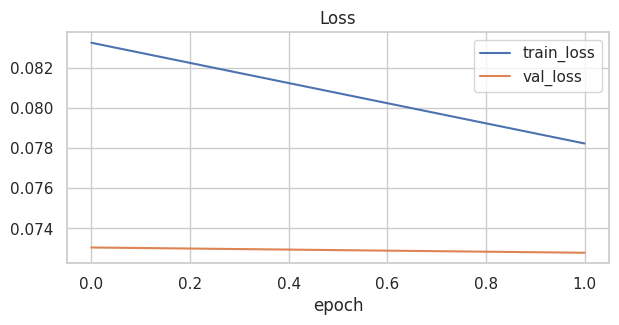

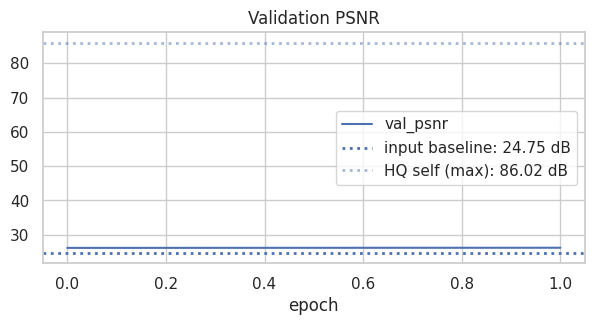

In [ ]:
# --- Train (quick sanity run) ---
from ml_engine.trainer import psnr as _psnr

psnr_data_range = 2.0  # because tensors are normalized to [-1, 1]
psnr_eps = 1e-8        # must match eps used in ml_engine.trainer.psnr()

@torch.no_grad()
def baseline_input_psnr(loader, max_batches=50) -> float:
    """PSNR of degraded input (LQ) vs target (HQ), before any model."""
    total = 0.0
    n = 0
    for i, batch in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        lq = batch["lq"].to(device, non_blocking=True)
        hq = batch["hq"].to(device, non_blocking=True)
        total += _psnr(lq, hq, data_range=psnr_data_range, eps=psnr_eps)
        n += 1
    return total / max(1, n)

baseline_psnr = baseline_input_psnr(val_loader, max_batches=50)
perfect_psnr = (20.0 * math.log10(psnr_data_range)) - (10.0 * math.log10(psnr_eps))
print(f"Baseline input PSNR (LQ→HQ): {baseline_psnr:.2f} dB")
print(f"Theoretical max PSNR (HQ→HQ, due to eps clamp): {perfect_psnr:.2f} dB")

epochs = 2
history = train_image_to_image(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    lr=2e-4,
    weight_decay=0.0,
    loss_fn=loss_fn,
    max_train_batches=200,   # keep runtime reasonable; raise/remove for full training
    max_val_batches=50,
    grad_clip_norm=1.0,
    psnr_data_range=psnr_data_range,
 )

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_loss"], label="train_loss")
ax.plot(history["val_loss"], label="val_loss")
ax.set_xlabel("epoch")
ax.set_title("Loss")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["val_psnr"], label="val_psnr")
ax.axhline(baseline_psnr, linestyle=":", linewidth=2, label=f"input baseline: {baseline_psnr:.2f} dB")
ax.axhline(perfect_psnr, linestyle=":", linewidth=2, alpha=0.5, label=f"HQ self (max): {perfect_psnr:.2f} dB")
ax.set_xlabel("epoch")
ax.set_title("Validation PSNR")
ax.legend()
plt.show()

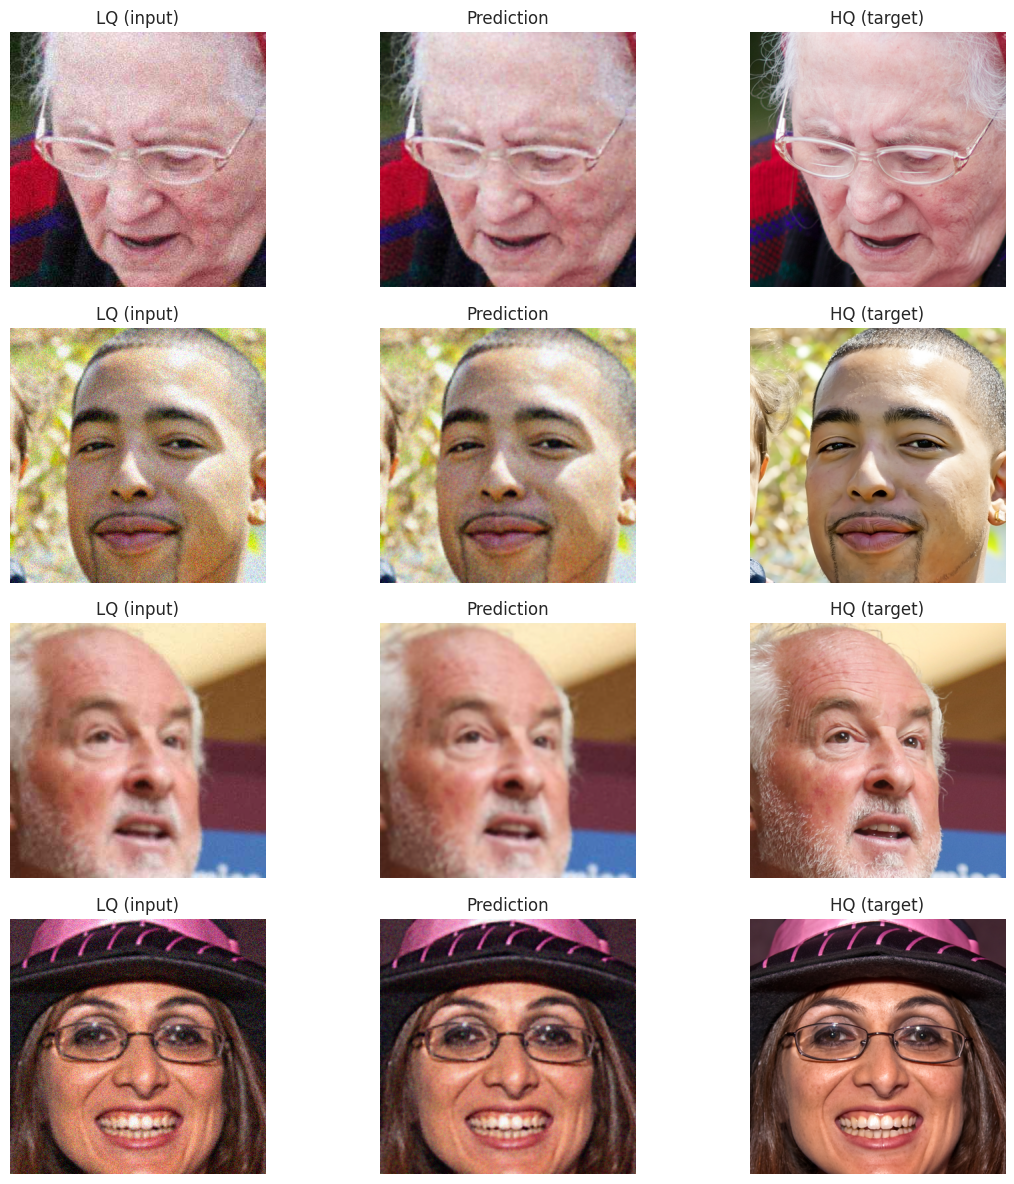

In [ ]:
# --- Visualize predictions on a few validation samples ---
model.eval()
batch = next(iter(val_loader))
lq = batch["lq"].to(device)
hq = batch["hq"].to(device)

with torch.no_grad():
    pred = model(lq)

# Convert to display range [0,1] using the helper from Cell 7
lq_vis = _denorm(lq).cpu()
pred_vis = _denorm(pred).cpu()
hq_vis = _denorm(hq).cpu()

n = min(4, lq_vis.shape[0])
fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3 * n))
if n == 1:
    axes = [axes]
for i in range(n):
    axes[i][0].imshow(lq_vis[i].permute(1, 2, 0))
    axes[i][0].set_title("LQ (input)")
    axes[i][0].axis("off")

    axes[i][1].imshow(pred_vis[i].permute(1, 2, 0))
    axes[i][1].set_title("Prediction")
    axes[i][1].axis("off")

    axes[i][2].imshow(hq_vis[i].permute(1, 2, 0))
    axes[i][2].set_title("HQ (target)")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# --- Quick validation metrics snapshot ---
metrics = evaluate_image_to_image(
    model=model,
    loader=val_loader,
    loss_fn=loss_fn,
    device=device,
    max_batches=50,
    psnr_data_range=2.0,
)
print(metrics)

{'loss': 0.07331474855542183, 'psnr': 26.143887100219725}


In [ ]:
# --- W&B logging toggle (optional) ---
import wandb

USE_WANDB = True  # set True to log runs / sweeps to Weights & Biases
WANDB_PROJECT = "cnn-image-enhancement"
WANDB_ENTITY = entity  # from the earlier cell (course entity)

if USE_WANDB:
    # Prompts in browser if needed, otherwise uses existing login
    wandb.login()

# For sweeps: where to save the best local checkpoint across runs
SWEEP_CKPT_DIR = project_root / "checkpoints" / "enhancement_sweep"
SWEEP_CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"USE_WANDB={USE_WANDB}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rmk024 (bucknell-university-csci357-2026sp) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


USE_WANDB=True


In [20]:
# --- Define a sweep config for the enhancement CNN ---
import numpy as np

# Track best model across sweep runs (in this kernel session)
BEST = {"val_psnr": -1e9, "ckpt": None, "config": None}

sweep_config = {
    "method": "random",
    "metric": {"name": "val_psnr", "goal": "maximize"},
    "parameters": {
        # Model size knobs
        "features": {"values": [32, 48, 64]},
        "num_blocks": {"values": [4, 6, 8, 10]},
        "residual": {"values": [True]},
        # Optimization
        "lr": {"distribution": "log_uniform_values", "min": 1e-5, "max": 5e-4},
        "weight_decay": {"values": [0.0, 1e-6, 1e-5]},
        "epochs": {"values": [10]},
        "max_val_batches": {"values": [25, 50]},
    },
}

print("Sweep config ready.")

Sweep config ready.


In [14]:
# --- Sweep train function (uses the engine) ---
from ml_engine.model import EnhancementCNN
from ml_engine.trainer import train_image_to_image, evaluate_image_to_image

def _wandb_log_fn():
    # wandb.log wants step as int; we log each epoch.
    def _log(payload: dict[str, float]) -> None:
        wandb.log({
            "train_loss": payload["train_loss"],
            "val_loss": payload["val_loss"],
            "val_psnr": payload["val_psnr"],
            "epoch": int(payload["epoch"]),
        }, step=int(payload["epoch"]))
    return _log

def sweep_train_one_run() -> None:
    # Must call wandb.init() before accessing wandb.config
    with wandb.init() as run:
        cfg = wandb.config
        run.name = (
            f"enh_cnn_f{cfg.features}_b{cfg.num_blocks}_lr{cfg.lr:.1e}_wd{cfg.weight_decay:.1e}"
        )

        # Allow max_train_batches to be omitted from sweep_config (=> full epoch)
        max_train_batches = getattr(cfg, "max_train_batches", None)
        if max_train_batches is not None:
            max_train_batches = int(max_train_batches)

        # Build model from sweep config
        m = EnhancementCNN(
            in_channels=3,
            out_channels=3,
            features=int(cfg.features),
            num_blocks=int(cfg.num_blocks),
            residual=bool(cfg.residual),
        ).to(device)

        # Train with optional W&B logging per epoch
        history = train_image_to_image(
            model=m,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            epochs=int(cfg.epochs),
            lr=float(cfg.lr),
            weight_decay=float(cfg.weight_decay),
            loss_fn=loss_fn,
            max_train_batches=max_train_batches,
            max_val_batches=int(cfg.max_val_batches),
            grad_clip_norm=1.0,
            psnr_data_range=psnr_data_range,
            log_fn=_wandb_log_fn(),
        )

        # Final metrics snapshot (log as summary)
        metrics = evaluate_image_to_image(
            model=m,
            loader=val_loader,
            loss_fn=loss_fn,
            device=device,
            max_batches=int(cfg.max_val_batches),
            psnr_data_range=psnr_data_range,
        )
        wandb.log({"val_loss_final": metrics["loss"], "val_psnr_final": metrics["psnr"]})
        run.summary["val_loss"] = metrics["loss"]
        run.summary["val_psnr"] = metrics["psnr"]

        # Save the checkpoint inside the W&B run dir so it's uploaded to the run's files.
        ckpt_name = f"{run.id}.pt"
        ckpt_path = Path(run.dir) / ckpt_name
        torch.save({
            "model_state_dict": m.state_dict(),
            "config": dict(cfg),
            "val_psnr": float(metrics["psnr"]),
            "val_loss": float(metrics["loss"]),
        }, ckpt_path)
        # Ensure the file is uploaded to W&B (sync at end of run).
        wandb.save(str(ckpt_path), base_path=run.dir, policy="end")

        if float(metrics["psnr"]) > float(BEST["val_psnr"]):
            BEST["val_psnr"] = float(metrics["psnr"])
            BEST["ckpt"] = str(ckpt_path)
            BEST["config"] = dict(cfg)
            print("New BEST:", BEST["val_psnr"], "dB", "->", BEST["ckpt"])


In [24]:
# --- Run the sweep (optional) ---
RUN_SWEEP = True  # set True to run the sweep
SWEEP_COUNT = 8     # number of runs to launch
if RUN_SWEEP:
    if not USE_WANDB:
        raise RuntimeError("Set USE_WANDB=True before running a W&B sweep.")
    sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
    print("Sweep ID:", sweep_id)
    wandb.agent(sweep_id, function=sweep_train_one_run, count=SWEEP_COUNT)
else:
    print("Sweep not started. Set RUN_SWEEP=True to run it.")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Create sweep with ID: zlcy3kl9
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/cnn-image-enhancement/sweeps/zlcy3kl9
Sweep ID: zlcy3kl9


wandb: Agent Starting Run: j24dxbg3 with config:
wandb: 	epochs: 10
wandb: 	features: 32
wandb: 	lr: 0.00017794490892726562
wandb: 	max_val_batches: 50
wandb: 	num_blocks: 10
wandb: 	residual: True
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/10 | train_loss=0.0745 | val_loss=0.0680 | val_psnr=26.81
Epoch 2/10 | train_loss=0.0703 | val_loss=0.0703 | val_psnr=26.36
Epoch 3/10 | train_loss=0.0696 | val_loss=0.0639 | val_psnr=27.37
Epoch 4/10 | train_loss=0.0694 | val_loss=0.0648 | val_psnr=27.02
Epoch 5/10 | train_loss=0.0683 | val_loss=0.0708 | val_psnr=26.37
Epoch 6/10 | train_loss=0.0699 | val_loss=0.0678 | val_psnr=26.88
Epoch 7/10 | train_loss=0.0677 | val_loss=0.0739 | val_psnr=26.02
Epoch 8/10 | train_loss=0.0677 | val_loss=0.0682 | val_psnr=26.58
Epoch 9/10 | train_loss=0.0692 | val_loss=0.0661 | val_psnr=26.96
Epoch 10/10 | train_loss=0.0683 | val_loss=0.0671 | val_psnr=26.67
New BEST: 26.728378715515138 dB -> /content/drive/MyDrive/csci357_final/checkpoints/enhancement_sweep/j24dxbg3.pt


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▃▁▁▂▂
val_loss,▄▅▁▂▆▄█▄▃▃
val_loss_final,▁
val_psnr,▅▃█▆▃▅▁▄▆▄
val_psnr_final,▁
epoch,10
train_loss,0.06828
val_loss,0.06715
val_loss_final,0.06715
val_psnr,26.72838


...

Epoch 1/10 | train_loss=0.0847 | val_loss=0.0843 | val_psnr=25.08
Epoch 2/10 | train_loss=0.0767 | val_loss=0.0808 | val_psnr=25.20
Epoch 3/10 | train_loss=0.0739 | val_loss=0.0829 | val_psnr=25.22
Epoch 4/10 | train_loss=0.0731 | val_loss=0.0682 | val_psnr=26.37
Epoch 5/10 | train_loss=0.0722 | val_loss=0.0743 | val_psnr=26.19
Epoch 6/10 | train_loss=0.0721 | val_loss=0.0780 | val_psnr=25.73
Epoch 7/10 | train_loss=0.0720 | val_loss=0.0729 | val_psnr=26.17
Epoch 8/10 | train_loss=0.0701 | val_loss=0.0603 | val_psnr=27.58
Epoch 9/10 | train_loss=0.0709 | val_loss=0.0873 | val_psnr=24.92
Epoch 10/10 | train_loss=0.0707 | val_loss=0.0658 | val_psnr=26.80


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▂▁▁▁
val_loss,▇▆▇▃▅▆▄▁█▂
val_loss_final,▁
val_psnr,▁▂▂▅▄▃▄█▁▆
val_psnr_final,▁
epoch,10
train_loss,0.07072
val_loss,0.07149
val_loss_final,0.07149
val_psnr,26.43741


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: c0wqdrsc with config:
wandb: 	epochs: 10
wandb: 	features: 64
wandb: 	lr: 9.820867909621796e-05
wandb: 	max_val_batches: 50
wandb: 	num_blocks: 4
wandb: 	residual: True
wandb: 	weight_decay: 1e-06
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 1/10 | train_loss=0.0742 | val_loss=0.0712 | val_psnr=26.16
Epoch 2/10 | train_loss=0.0709 | val_loss=0.0687 | val_psnr=26.67
Epoch 3/10 | train_loss=0.0699 | val_loss=0.0705 | val_psnr=26.41
Epoch 4/10 | train_loss=0.0695 | val_loss=0.0699 | val_psnr=26.44
Epoch 5/10 | train_loss=0.0687 | val_loss=0.0638 | val_psnr=27.24
Epoch 6/10 | train_loss=0.0688 | val_loss=0.0711 | val_psnr=26.42
Epoch 7/10 | train_loss=0.0679 | val_loss=0.0661 | val_psnr=26.75
Epoch 8/10 | train_loss=0.0679 | val_loss=0.0704 | val_psnr=26.42
Epoch 9/10 | train_loss=0.0686 | val_loss=0.0656 | val_psnr=26.90
Epoch 10/10 | train_loss=0.0680 | val_loss=0.0625 | val_psnr=27.39


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▂▁▁▂▁
val_loss,█▆▇▇▂█▄▇▃▁
val_loss_final,▁
val_psnr,▁▄▂▃▇▂▄▂▅█
val_psnr_final,▁
epoch,10
train_loss,0.06802
val_loss,0.06664
val_loss_final,0.06664
val_psnr,26.73966


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/ryankoes/.netrc.


Project root: /Users/ryankoes/Downloads/Image Enhancement Tool
Sweep: zlcy3kl9  (8 runs with 'val_psnr')
Best run: enh_cnn_f32_b6_lr5.0e-04_wd1.0e-06 (id=yshsw1yh) | val_psnr=27.1702

Best run config:
{
  "lr": 0.0004968277282446104,
  "epochs": 10,
  "features": 32,
  "residual": true,
  "num_blocks": 6,
  "weight_decay": 1e-06,
  "max_val_batches": 50
}

Best run summary metrics:
{
  "val_psnr": 27.17020622253418,
  "val_loss": 0.06396894797682762,
  "val_psnr_final": 27.17020622253418,
  "val_loss_final": 0.06396894797682762,
  "train_loss": 0.06898002211252849,
  "epoch": 10
}

Top 5 runs by val_psnr:
   27.170  yshsw1yh  enh_cnn_f32_b6_lr5.0e-04_wd1.0e-06
   27.121  n6ro7ov8  enh_cnn_f32_b8_lr2.3e-04_wd0.0e+00
   26.740  c0wqdrsc  enh_cnn_f64_b4_lr9.8e-05_wd1.0e-06
   26.728  j24dxbg3  enh_cnn_f32_b10_lr1.8e-04_wd1.0e-05
   26.472  ofs57f5t  enh_cnn_f32_b10_lr8.7e-05_wd0.0e+00


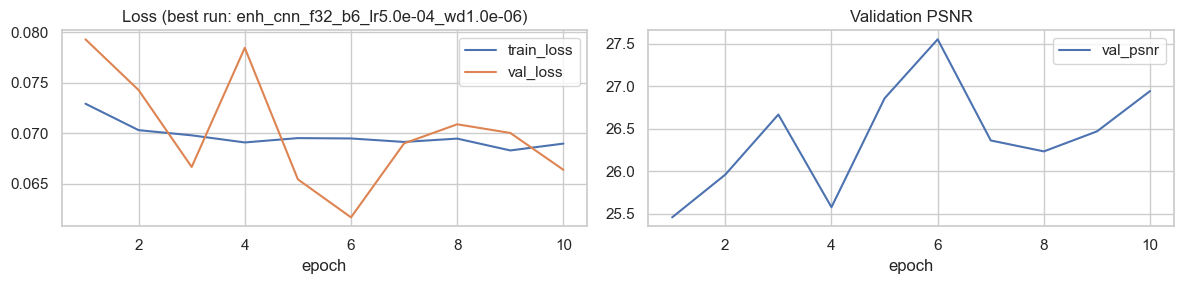


Note: no model weights are available on W&B for this sweep, so prediction visualization is skipped. Future sweeps will upload checkpoints automatically.


In [15]:
# --- Pull best-run info from a W&B sweep (no local checkpoints required) ---
import json
import tempfile

project_root = _ensure_src_on_path()
print(f"Project root: {project_root}")

import wandb

project = "cnn-image-enhancement"

# Set this to the sweep ID you want to load (just the ID, not the full path).
# You can also paste a full path like "entity/project/sweep_id" and it will be parsed.
SWEEP_ID = "zlcy3kl9"

# Metric to rank runs by (higher is better for PSNR).
SWEEP_METRIC = "val_psnr"


def _resolve_sweep_path(sweep_id: str) -> str:
    """Accept either a bare sweep id or a fully qualified entity/project/id path."""
    sweep_id = sweep_id.strip()
    if not sweep_id:
        raise ValueError("SWEEP_ID is empty. Paste a sweep id from W&B above.")
    if sweep_id.count("/") == 2:
        return sweep_id
    return f"{entity}/{project}/{sweep_id}"


api = wandb.Api()
sweep = api.sweep(_resolve_sweep_path(SWEEP_ID))

# Rank all runs in the sweep by SWEEP_METRIC (skip runs without the metric).
scored_runs = [
    (r, r.summary.get(SWEEP_METRIC))
    for r in sweep.runs
    if r.summary.get(SWEEP_METRIC) is not None
]
if not scored_runs:
    raise RuntimeError(f"No runs in sweep {SWEEP_ID} have metric '{SWEEP_METRIC}' logged yet.")

scored_runs.sort(key=lambda rm: float(rm[1]), reverse=True)
best_run, best_metric = scored_runs[0]

print(f"Sweep: {sweep.id}  ({len(scored_runs)} runs with '{SWEEP_METRIC}')")
print(f"Best run: {best_run.name} (id={best_run.id}) | {SWEEP_METRIC}={float(best_metric):.4f}")
print()

# Pull hyperparameters and final metrics from W&B (no checkpoint needed).
best_config = dict(best_run.config)
best_summary = {
    k: best_run.summary.get(k)
    for k in ("val_psnr", "val_loss", "val_psnr_final", "val_loss_final", "train_loss", "epoch")
    if best_run.summary.get(k) is not None
}

print("Best run config:")
print(json.dumps(best_config, indent=2, default=str))
print("\nBest run summary metrics:")
print(json.dumps(best_summary, indent=2, default=str))

# Top-N leaderboard
TOP_N = min(5, len(scored_runs))
print(f"\nTop {TOP_N} runs by {SWEEP_METRIC}:")
for r, m in scored_runs[:TOP_N]:
    print(f"  {float(m):>7.3f}  {r.id}  {r.name}")

# Try to fetch the per-epoch history (loss/psnr curves) for the best run.
try:
    hist_df = best_run.history(
        keys=["epoch", "train_loss", "val_loss", "val_psnr"],
        pandas=True,
    )
except Exception as exc:
    print(f"\nCould not fetch run history: {exc}")
    hist_df = None

if hist_df is not None and len(hist_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    if "train_loss" in hist_df:
        axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    if "val_loss" in hist_df:
        axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_title(f"Loss (best run: {best_run.name})")
    axes[0].legend()

    if "val_psnr" in hist_df:
        axes[1].plot(hist_df["epoch"], hist_df["val_psnr"], label="val_psnr")
    axes[1].set_xlabel("epoch")
    axes[1].set_title("Validation PSNR")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nNo per-epoch history available for this run.")

# Note: this sweep's runs did not upload model checkpoints (.pt) to W&B, so the
# trained weights cannot be recovered remotely. To enable best-model visualization
# in the future, re-run a sweep with the updated training cell that calls
# `wandb.save(...)` on the checkpoint inside `run.dir`.
print(
    "\nNote: no model weights are available on W&B for this sweep, so prediction "
    "visualization is skipped. Future sweeps will upload checkpoints automatically."
)


In [17]:
# --- Run example images through the best model using local checkpoints ---
from ml_engine.model import EnhancementCNN

LOCAL_CKPT_DIR = project_root / "checkpoints" / "enhancement_sweep"
print(f"Looking for checkpoints in: {LOCAL_CKPT_DIR}")

# Use the W&B-derived `scored_runs` (sorted best -> worst by SWEEP_METRIC) and
# pick the highest-ranked run that also has a local .pt file.
best_local_run = None
best_local_metric = None
for r, metric in scored_runs:
    if (LOCAL_CKPT_DIR / f"{r.id}.pt").exists():
        best_local_run = r
        best_local_metric = float(metric)
        break

if best_local_run is None:
    available = sorted(p.stem for p in LOCAL_CKPT_DIR.glob("*.pt"))
    raise FileNotFoundError(
        f"None of the W&B sweep runs have a matching local checkpoint in {LOCAL_CKPT_DIR}.\n"
        f"Available local run ids: {available}"
    )

ckpt_path = LOCAL_CKPT_DIR / f"{best_local_run.id}.pt"
print(
    f"Using local checkpoint for best available run: {best_local_run.name} "
    f"(id={best_local_run.id}) | {SWEEP_METRIC}={best_local_metric:.4f}"
)
print(f"Checkpoint: {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location=accel_device)
cfg = ckpt.get("config", dict(best_local_run.config))

best_model = EnhancementCNN(
    in_channels=3,
    out_channels=3,
    features=int(cfg.get("features", 64)),
    num_blocks=int(cfg.get("num_blocks", 8)),
    residual=bool(cfg.get("residual", True)),
).to(accel_device)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

batch = next(iter(val_loader))
lq = batch["lq"].to(accel_device)
hq = batch["hq"].to(accel_device)
with torch.no_grad():
    pred = best_model(lq)

lq_vis = _denorm(lq).cpu()
pred_vis = _denorm(pred).cpu()
hq_vis = _denorm(hq).cpu()

n = min(4, lq_vis.shape[0])
fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3 * n))
if n == 1:
    axes = [axes]
for i in range(n):
    axes[i][0].imshow(lq_vis[i].permute(1, 2, 0))
    axes[i][0].set_title("LQ (input)")
    axes[i][0].axis("off")

    axes[i][1].imshow(pred_vis[i].permute(1, 2, 0))
    axes[i][1].set_title(f"Best sweep pred ({best_local_metric:.2f} dB)")
    axes[i][1].axis("off")

    axes[i][2].imshow(hq_vis[i].permute(1, 2, 0))
    axes[i][2].set_title("HQ (target)")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()


Looking for checkpoints in: /Users/ryankoes/Downloads/Image Enhancement Tool/checkpoints/enhancement_sweep
Using local checkpoint for best available run: enh_cnn_f32_b6_lr5.0e-04_wd1.0e-06 (id=yshsw1yh) | val_psnr=27.1702
Checkpoint: /Users/ryankoes/Downloads/Image Enhancement Tool/checkpoints/enhancement_sweep/yshsw1yh.pt


NameError: name 'val_loader' is not defined